# 08. Confounders, Mediators, Colliders, and Selection Bias

In the previous lecture, we learned how to read causal DAGs. This notebook turns that graph language into one of the most important practical skills in causal inference:

> deciding what to adjust for, what not to adjust for, and what to treat as part of the causal mechanism.

This is where many applied causal projects go wrong. A variable can be strongly predictive of the outcome and still be a bad control. A variable can be correlated with treatment and outcome and still not be a confounder. A variable can make a regression look more complete while moving the estimand away from the business question.

We will focus on four roles:

1. **Confounders**: common causes of treatment and outcome.
2. **Mediators**: variables on the causal pathway from treatment to outcome.
3. **Colliders**: common effects of two or more causes.
4. **Selection variables**: variables that determine whether a unit enters the data or analysis.

The goal is not to memorize labels. The goal is to learn how to reason from the graph, the timing, and the estimand.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain why a confounder is a causal role, not just a statistical association.
- Show with code why adjusting for a confounder can reduce bias.
- Show with code why adjusting for a mediator changes a total-effect estimand.
- Show with code why conditioning on a collider can create association from nothing.
- Recognize selection bias as conditioning on entry into the observed data.
- Build an adjustment checklist for industry causal inference projects.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from graphviz import Digraph
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(20260428)

COLORS = {
    "treatment": "#d7ecff",
    "outcome": "#ffd6db",
    "confounder": "#dff0d8",
    "mediator": "#eadcf8",
    "collider": "#fff1c7",
    "selection": "#ffe0c2",
    "latent": "#e0e0e0",
    "neutral": "#f7f7f7",
}

In [2]:
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """Create a Graphviz DAG with consistent lecture styling."""
    node_colors = node_colors or {}
    dot = Digraph(format="svg")
    dot.attr(rankdir=rankdir, bgcolor="transparent", pad="0.15", nodesep="0.5", ranksep="0.65")
    dot.attr("node", shape="box", style="rounded,filled", color="#2b2b2b", fontname="Helvetica", fontsize="11", margin="0.12,0.08")
    dot.attr("edge", color="#404040", arrowsize="0.75", penwidth="1.6", fontname="Helvetica", fontsize="10")
    if title:
        dot.attr(label=title, labelloc="t", fontsize="14", fontname="Helvetica-Bold")
    nodes = sorted(set([node for edge in edges for node in edge[:2]]))
    for node in nodes:
        dot.node(node, fillcolor=node_colors.get(node, COLORS["neutral"]))
    for edge in edges:
        if len(edge) == 2:
            src, dst = edge
            attrs = {}
        else:
            src, dst, attrs = edge
        dot.edge(src, dst, **attrs)
    return dot


def coef_table(models, variable):
    rows = []
    for name, model in models.items():
        rows.append({
            "model": name,
            "coefficient": model.params[variable],
            "std_error": model.bse[variable],
            "lower_95": model.params[variable] - 1.96 * model.bse[variable],
            "upper_95": model.params[variable] + 1.96 * model.bse[variable],
            "r_squared": getattr(model, "rsquared", np.nan),
        })
    return pd.DataFrame(rows)


def plot_coef_table(table, title, xlabel, reference=None, figsize=(8, 3.8), ax=None):
    owns_figure = ax is None
    if owns_figure:
        fig, ax = plt.subplots(figsize=figsize)
    ax.errorbar(
        table["coefficient"],
        table["model"],
        xerr=[table["coefficient"] - table["lower_95"], table["upper_95"] - table["coefficient"]],
        fmt="o",
        color="#2f6f9f",
        capsize=4,
    )
    ax.axvline(0, color="black", linewidth=1)
    if reference is not None:
        ax.axvline(reference, color="#b23a48", linestyle="--", label=f"Reference: {reference:.2f}")
        ax.legend(loc="best")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    if owns_figure:
        plt.tight_layout()
        plt.show()

## 1. The Same Variable Can Have Different Causal Roles

A variable's role depends on the graph and the estimand. The name of the column is not enough.

For example, `engagement` could be:

- a confounder if past engagement affects both treatment assignment and future revenue;
- a mediator if a product change increases engagement and engagement increases revenue;
- a collider if engagement is caused by both treatment and latent interest;
- a selection variable if only engaged users remain in the analysis dataset.

This is why causal adjustment cannot be done by blindly controlling for every available feature. DAGs help us classify variables by their causal role (Greenland et al., 1999; Suttorp et al., 2014; Howards et al., 2012).

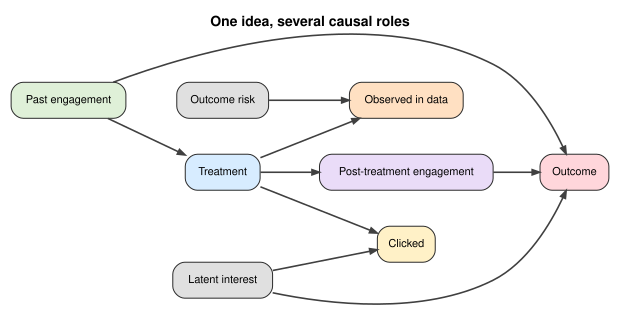

In [3]:
role_edges = [
    ("Past engagement", "Treatment"),
    ("Past engagement", "Outcome"),
    ("Treatment", "Post-treatment engagement"),
    ("Post-treatment engagement", "Outcome"),
    ("Treatment", "Clicked"),
    ("Latent interest", "Clicked"),
    ("Latent interest", "Outcome"),
    ("Treatment", "Observed in data"),
    ("Outcome risk", "Observed in data"),
]
role_colors = {
    "Treatment": COLORS["treatment"],
    "Outcome": COLORS["outcome"],
    "Past engagement": COLORS["confounder"],
    "Post-treatment engagement": COLORS["mediator"],
    "Clicked": COLORS["collider"],
    "Latent interest": COLORS["latent"],
    "Observed in data": COLORS["selection"],
    "Outcome risk": COLORS["latent"],
}

display(make_dag(role_edges, "One idea, several causal roles", role_colors))

### Interpretation

The graph shows why timing is not a cosmetic detail.

- `Past engagement` is measured before treatment and may confound the treatment-outcome relationship.
- `Post-treatment engagement` is caused by treatment and may mediate the treatment effect.
- `Clicked` is a common effect of treatment and latent interest, so conditioning on click can create collider bias.
- `Observed in data` is a selection node. If analysis includes only observed units, we have conditioned on that node.

A serious causal analysis should include a variable timing table before fitting models.

## 2. A Compact Adjustment Taxonomy

Here is a first-pass taxonomy for total-effect questions.

| Role | Graph pattern | Usual action for total effect | Reason |
|---|---|---|---|
| Confounder | `T <- X -> Y` | Adjust | Blocks a back-door path |
| Outcome predictor only | `X -> Y` | Optional | Can improve precision, not needed for bias |
| Treatment predictor only | `X -> T` | Usually optional | May help design diagnostics, not needed for bias |
| Mediator | `T -> M -> Y` | Do not adjust | Blocks part of the total effect |
| Collider | `T -> C <- U` | Do not condition | Opens a non-causal path |
| Selection variable | `T -> S <- U -> Y` and analyze `S = 1` | Avoid or correct | Analysis is conditioned on a collider-like entry process |
| Instrument-like variable | `Z -> T -> Y` | Do not treat as ordinary confounder | Can be useful for IV, but not a standard control |

The word "usual" matters. Some projects target direct effects, mediation effects, or principal strata. Those are different estimands with different adjustment logic.

In [4]:
taxonomy = pd.DataFrame({
    "role": [
        "Confounder",
        "Outcome predictor only",
        "Treatment predictor only",
        "Mediator",
        "Collider",
        "Selection variable",
        "Instrument-like variable",
    ],
    "graph_pattern": [
        "T <- X -> Y",
        "X -> Y",
        "X -> T",
        "T -> M -> Y",
        "T -> C <- U",
        "T -> S <- U -> Y, analyze S=1",
        "Z -> T -> Y",
    ],
    "total_effect_action": [
        "Adjust",
        "Optional for precision",
        "Usually not needed for bias",
        "Avoid ordinary adjustment",
        "Avoid conditioning",
        "Avoid restriction; consider correction/sensitivity",
        "Not an ordinary control",
    ],
})
taxonomy

,role,graph_pattern,total_effect_action
0,Confounder,T <- X -> Y,Adjust
1,Outcome predictor only,X -> Y,Optional for precision
2,Treatment predictor only,X -> T,Usually not needed for bias
3,Mediator,T -> M -> Y,Avoid ordinary adjustment
4,Collider,T -> C <- U,Avoid conditioning
5,Selection variable,"T -> S <- U -> Y, analyze S=1",Avoid restriction; consider correction/sensiti...
6,Instrument-like variable,Z -> T -> Y,Not an ordinary control


## 3. Confounders: Common Causes That Create Back-Door Paths

A confounder is a common cause of treatment and outcome. It creates an open, non-causal path between treatment and outcome.

In an industry marketing example, suppose a campaign is more likely to be shown to high-demand customers. Those customers would have purchased at higher rates even without the campaign. If we compare exposed and unexposed customers directly, we will attribute pre-existing demand differences to the campaign.

The DAG is:

$$
\text{Prior demand} \rightarrow \text{Campaign exposure},
\qquad
\text{Prior demand} \rightarrow \text{Purchase},
\qquad
\text{Campaign exposure} \rightarrow \text{Purchase}.
$$

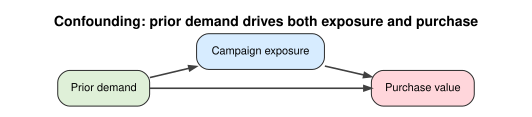

In [5]:
confounder_edges = [
    ("Prior demand", "Campaign exposure"),
    ("Prior demand", "Purchase value"),
    ("Campaign exposure", "Purchase value"),
]
confounder_colors = {
    "Campaign exposure": COLORS["treatment"],
    "Purchase value": COLORS["outcome"],
    "Prior demand": COLORS["confounder"],
}

display(make_dag(confounder_edges, "Confounding: prior demand drives both exposure and purchase", confounder_colors))

In [6]:
def simulate_campaign_confounding(n=70_000, seed=1):
    rng_local = np.random.default_rng(seed)
    prior_demand = rng_local.normal(size=n)
    p_exposed = 1 / (1 + np.exp(-(-0.15 + 1.25 * prior_demand)))
    exposed = rng_local.binomial(1, p_exposed)
    true_effect = 1.50
    purchase_value = 4.0 + true_effect * exposed + 2.10 * prior_demand + rng_local.normal(scale=1.3, size=n)
    return pd.DataFrame({
        "prior_demand": prior_demand,
        "exposed": exposed,
        "purchase_value": purchase_value,
        "p_exposed": p_exposed,
    }), true_effect

df_campaign, true_campaign_effect = simulate_campaign_confounding()

campaign_models = {
    "Naive: outcome ~ treatment": smf.ols("purchase_value ~ exposed", data=df_campaign).fit(),
    "Adjusted: add prior demand": smf.ols("purchase_value ~ exposed + prior_demand", data=df_campaign).fit(),
}

campaign_table = coef_table(campaign_models, "exposed")
campaign_table.round(3)

,model,coefficient,std_error,lower_95,upper_95,r_squared
0,Naive: outcome ~ treatment,3.492,0.017,3.458,3.525,0.374
1,Adjusted: add prior demand,1.500,0.011,1.478,1.522,0.792


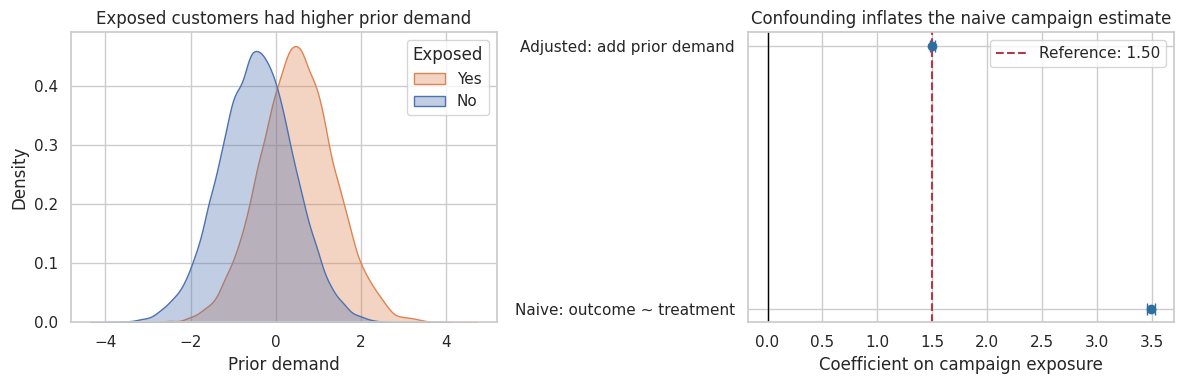

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(
    data=df_campaign,
    x="prior_demand",
    hue="exposed",
    fill=True,
    common_norm=False,
    alpha=0.35,
    ax=axes[0],
)
axes[0].set_title("Exposed customers had higher prior demand")
axes[0].set_xlabel("Prior demand")
axes[0].legend(title="Exposed", labels=["Yes", "No"])

plot_coef_table(
    campaign_table,
    title="Confounding inflates the naive campaign estimate",
    xlabel="Coefficient on campaign exposure",
    reference=true_campaign_effect,
    ax=axes[1],
)

plt.tight_layout()
plt.show()

### Interpretation

The naive campaign estimate is too large because exposure is targeted toward customers with higher prior demand. The adjusted model compares exposed and unexposed customers with similar prior demand, so it moves toward the true campaign effect used in the data-generating process.

This illustrates the core logic of confounding control:

$$
\text{Back-door path: } T \leftarrow X \rightarrow Y.
$$

Adjusting for `X` blocks the back-door path. That is why `prior_demand` belongs in a total-effect adjustment set.

## 4. Association Is Not Enough to Define a Confounder

A common mistake is to label a variable as a confounder if it is associated with treatment and outcome in the observed data. That rule is incomplete.

A variable can be associated with treatment and outcome because:

- it is a true common cause;
- it is caused by treatment;
- it is caused by outcome or by a cause of outcome;
- it is a collider or descendant of a collider;
- it is a proxy for an unobserved cause;
- the sample has already been selected in a biased way.

Graphical definitions are useful because they distinguish these cases. Howards et al. (2012) discuss how conventional confounder definitions can suggest adjustment for variables that would induce bias under some DAGs.

In [8]:
association_examples = pd.DataFrame({
    "variable": [
        "Prior demand",
        "Post-campaign click",
        "Survey response",
        "Eligibility score",
        "Historical segment label",
    ],
    "could_be_associated_with_treatment_and_outcome": ["Yes", "Yes", "Yes", "Yes", "Yes"],
    "causal_role_must_be_checked": [
        "Pre-treatment common cause",
        "Mediator or collider",
        "Selection variable",
        "Treatment assignment driver; may or may not affect outcome",
        "Proxy for underlying causes",
    ],
    "safe_default_for_total_effect": [
        "Likely adjust",
        "Do not adjust without a mediation estimand",
        "Do not restrict blindly",
        "Use graph and timing",
        "Use graph and sensitivity analysis",
    ],
})
association_examples

,variable,could_be_associated_with_treatment_and_outcome,causal_role_must_be_checked,safe_default_for_total_effect
0,Prior demand,Yes,Pre-treatment common cause,Likely adjust
1,Post-campaign click,Yes,Mediator or collider,Do not adjust without a mediation estimand
2,Survey response,Yes,Selection variable,Do not restrict blindly
3,Eligibility score,Yes,Treatment assignment driver; may or may not af...,Use graph and timing
4,Historical segment label,Yes,Proxy for underlying causes,Use graph and sensitivity analysis


## 5. Mediators: Part of the Causal Pathway

A mediator is caused by treatment and causes the outcome.

Example: a new onboarding flow increases feature activation, and feature activation increases 30-day retention.

If the business question is the total effect of the onboarding flow on retention, activation is not a confounder. It is part of the mechanism.

$$
\text{Onboarding flow} \rightarrow \text{Activation} \rightarrow \text{Retention}.
$$

Mediation analysis asks how much of an effect goes through a mediator, but that is a separate causal question requiring additional assumptions (Fulcher et al., 2019; Rijnhart et al., 2020).

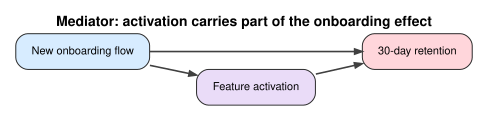

In [9]:
mediator_edges = [
    ("New onboarding flow", "Feature activation"),
    ("Feature activation", "30-day retention"),
    ("New onboarding flow", "30-day retention"),
]
mediator_colors = {
    "New onboarding flow": COLORS["treatment"],
    "30-day retention": COLORS["outcome"],
    "Feature activation": COLORS["mediator"],
}

display(make_dag(mediator_edges, "Mediator: activation carries part of the onboarding effect", mediator_colors))

In [10]:
def simulate_mediation(n=70_000, seed=2):
    rng_local = np.random.default_rng(seed)
    treatment = rng_local.binomial(1, 0.5, size=n)
    mediator = 0.85 * treatment + rng_local.normal(scale=1.0, size=n)
    direct_effect = 0.45
    mediator_to_outcome = 1.10
    outcome = 2.0 + direct_effect * treatment + mediator_to_outcome * mediator + rng_local.normal(scale=1.2, size=n)
    total_effect = direct_effect + 0.85 * mediator_to_outcome
    return pd.DataFrame({
        "treatment": treatment,
        "activation": mediator,
        "retention_score": outcome,
    }), direct_effect, total_effect

df_med, true_direct, true_total = simulate_mediation()

mediation_models = {
    "Total-effect model: Y ~ T": smf.ols("retention_score ~ treatment", data=df_med).fit(),
    "Direct-effect-style model: Y ~ T + M": smf.ols("retention_score ~ treatment + activation", data=df_med).fit(),
}

mediation_table = coef_table(mediation_models, "treatment")
mediation_table.round(3)

,model,coefficient,std_error,lower_95,upper_95,r_squared
0,Total-effect model: Y ~ T,1.397,0.012,1.373,1.422,0.155
1,Direct-effect-style model: Y ~ T + M,0.462,0.010,0.443,0.481,0.542


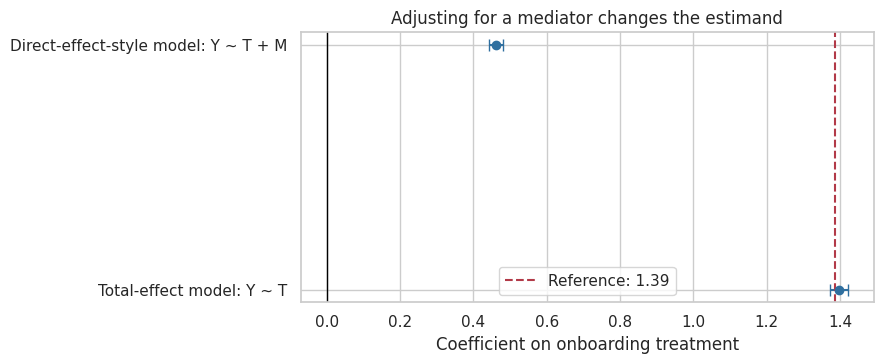

Approximate true total effect in this simulation: 1.385
Direct path coefficient in this simulation: 0.450


In [11]:
plot_coef_table(
    mediation_table,
    title="Adjusting for a mediator changes the estimand",
    xlabel="Coefficient on onboarding treatment",
    reference=true_total,
    figsize=(9, 3.8),
)
print(f"Approximate true total effect in this simulation: {true_total:.3f}")
print(f"Direct path coefficient in this simulation: {true_direct:.3f}")

### Interpretation

The model without the mediator estimates the total effect: the direct path plus the path through activation.

The model that adjusts for activation estimates something closer to a direct effect: holding activation fixed, how does treatment relate to retention? That is a legitimate question only if the estimand is direct-effect-like. It is not the same as the total business effect of rolling out the onboarding flow.

For total effects, controlling for post-treatment mediators often leads to **overadjustment**.

## 6. Mediator-Outcome Confounding

Mediation questions are harder than total-effect questions because the mediator-outcome relationship may itself be confounded.

For example, suppose motivation affects both feature activation and retention. Then estimating the indirect path through activation requires accounting for motivation. If motivation is unmeasured, the estimated mediation decomposition can be misleading.

The graph below separates the total-effect question from the mediation-decomposition question.

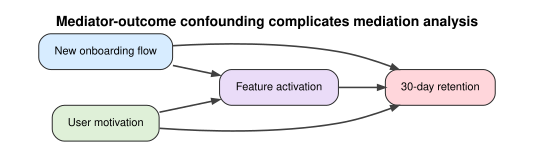

In [12]:
med_conf_edges = [
    ("New onboarding flow", "Feature activation"),
    ("Feature activation", "30-day retention"),
    ("New onboarding flow", "30-day retention"),
    ("User motivation", "Feature activation"),
    ("User motivation", "30-day retention"),
]
med_conf_colors = {
    "New onboarding flow": COLORS["treatment"],
    "Feature activation": COLORS["mediator"],
    "30-day retention": COLORS["outcome"],
    "User motivation": COLORS["confounder"],
}

display(make_dag(med_conf_edges, "Mediator-outcome confounding complicates mediation analysis", med_conf_colors))

### Practical Rule

When the estimand is a total effect, do not adjust for the mediator.

When the estimand is a mediation estimand, draw a separate mediation DAG and ask:

- Is treatment randomized or otherwise unconfounded?
- Are mediator-outcome common causes measured?
- Are any mediator-outcome confounders affected by treatment?
- Is the mediator measured accurately?
- Is the direct/indirect decomposition actually needed for the decision?

Many industry decisions only need the total effect. Do not make the problem harder unless the mechanism question matters.

## 7. Colliders: Common Effects That Open Paths

A collider is a variable caused by two or more variables. The basic pattern is:

$$
A \rightarrow C \leftarrow B.
$$

Without conditioning on `C`, this path is closed. After conditioning on `C`, the path opens and induces association between `A` and `B`.

Collider stratification bias is widely discussed in epidemiology and causal inference because it can create spurious associations when analysts restrict, stratify, match, or regress on common effects (Whitcomb et al., 2009; Lu et al., 2023; Banack et al., 2024).

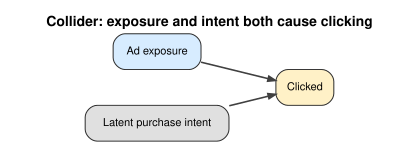

In [13]:
collider_edges = [
    ("Ad exposure", "Clicked"),
    ("Latent purchase intent", "Clicked"),
]
collider_colors = {
    "Ad exposure": COLORS["treatment"],
    "Latent purchase intent": COLORS["latent"],
    "Clicked": COLORS["collider"],
}

display(make_dag(collider_edges, "Collider: exposure and intent both cause clicking", collider_colors))

In [14]:
def simulate_basic_collider(n=80_000, seed=3):
    rng_local = np.random.default_rng(seed)
    exposure = rng_local.binomial(1, 0.5, size=n)
    intent = rng_local.normal(size=n)
    click_score = -0.25 + 1.1 * exposure + 1.1 * intent + rng_local.normal(size=n)
    clicked = (click_score > 0.7).astype(int)
    return pd.DataFrame({
        "exposure": exposure,
        "intent": intent,
        "clicked": clicked,
    })

df_col = simulate_basic_collider()

collider_corr = pd.DataFrame({
    "sample": ["All users", "Clicked users only"],
    "corr_exposure_intent": [
        np.corrcoef(df_col["exposure"], df_col["intent"])[0, 1],
        np.corrcoef(df_col.loc[df_col["clicked"] == 1, "exposure"], df_col.loc[df_col["clicked"] == 1, "intent"])[0, 1],
    ],
    "n": [len(df_col), int(df_col["clicked"].sum())],
})
collider_corr.round(3)

,sample,corr_exposure_intent,n
0,All users,0.002,80000
1,Clicked users only,-0.213,32131


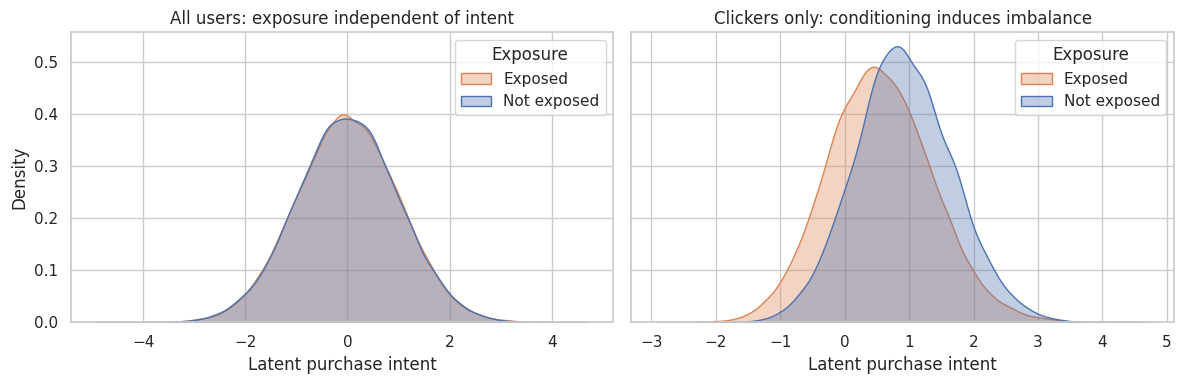

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.kdeplot(data=df_col, x="intent", hue="exposure", fill=True, common_norm=False, alpha=0.35, ax=axes[0])
axes[0].set_title("All users: exposure independent of intent")
axes[0].set_xlabel("Latent purchase intent")
axes[0].legend(title="Exposure", labels=["Exposed", "Not exposed"])

sns.kdeplot(data=df_col.query("clicked == 1"), x="intent", hue="exposure", fill=True, common_norm=False, alpha=0.35, ax=axes[1])
axes[1].set_title("Clickers only: conditioning induces imbalance")
axes[1].set_xlabel("Latent purchase intent")
axes[1].legend(title="Exposure", labels=["Exposed", "Not exposed"])

plt.tight_layout()
plt.show()

### Interpretation

In the full sample, ad exposure was randomized and independent of purchase intent. Among clickers only, exposure and intent become negatively related. Why?

Among people who clicked, the click can be explained by exposure, intent, or both. If a clicked user was exposed, they did not need as much latent intent to click. If a clicked user was not exposed, they needed higher latent intent to click.

That is collider logic. Conditioning on the common effect creates dependence between its causes.

## 8. Collider Bias Can Create a Fake Treatment Effect

Now let us connect the collider to an outcome. Suppose ad exposure has no true effect on purchase, but latent purchase intent affects both clicking and purchase. If we analyze only clickers, exposure can appear harmful because exposed clickers have lower average latent intent than unexposed clickers.

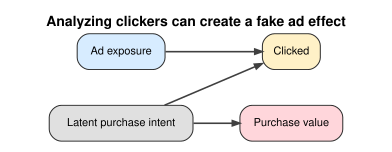

In [16]:
clicker_effect_edges = [
    ("Ad exposure", "Clicked"),
    ("Latent purchase intent", "Clicked"),
    ("Latent purchase intent", "Purchase value"),
]
clicker_effect_colors = {
    "Ad exposure": COLORS["treatment"],
    "Clicked": COLORS["collider"],
    "Latent purchase intent": COLORS["latent"],
    "Purchase value": COLORS["outcome"],
}

display(make_dag(clicker_effect_edges, "Analyzing clickers can create a fake ad effect", clicker_effect_colors))

In [17]:
def simulate_clicker_bias(n=100_000, seed=4):
    rng_local = np.random.default_rng(seed)
    exposure = rng_local.binomial(1, 0.5, size=n)
    intent = rng_local.normal(size=n)
    clicked = (-0.2 + 1.15 * exposure + 1.20 * intent + rng_local.normal(size=n) > 0.8).astype(int)
    # No true ad effect on purchase value.
    purchase_value = 5.0 + 0.0 * exposure + 1.6 * intent + rng_local.normal(scale=1.2, size=n)
    return pd.DataFrame({
        "exposure": exposure,
        "intent": intent,
        "clicked": clicked,
        "purchase_value": purchase_value,
    })

df_clicker = simulate_clicker_bias()

clicker_models = {
    "All users: Y ~ exposure": smf.ols("purchase_value ~ exposure", data=df_clicker).fit(),
    "Clickers only: Y ~ exposure": smf.ols("purchase_value ~ exposure", data=df_clicker.query("clicked == 1")).fit(),
    "Clickers only: add latent intent": smf.ols("purchase_value ~ exposure + intent", data=df_clicker.query("clicked == 1")).fit(),
}

clicker_table = coef_table(clicker_models, "exposure")
clicker_table.round(3)

,model,coefficient,std_error,lower_95,upper_95,r_squared
0,All users: Y ~ exposure,-0.004,0.013,-0.029,0.020,0.000
1,Clickers only: Y ~ exposure,-0.618,0.018,-0.654,-0.582,0.027
2,Clickers only: add latent intent,0.006,0.013,-0.020,0.031,0.540


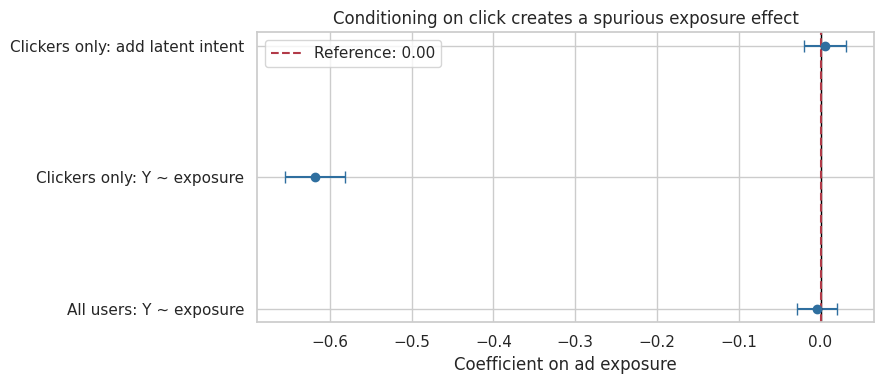

In [18]:
plot_coef_table(
    clicker_table,
    title="Conditioning on click creates a spurious exposure effect",
    xlabel="Coefficient on ad exposure",
    reference=0.0,
    figsize=(9, 4),
)

### Interpretation

In the full sample, the exposure coefficient is close to zero, which matches the simulation: ad exposure has no causal effect on purchase value.

Among clickers only, the exposure coefficient becomes negative. The analysis has conditioned on a collider, `Clicked`, which induces imbalance in latent intent. Once we adjust for the latent intent variable in the simulation, the fake effect disappears. In real projects, latent intent is often not observed, which is why click-conditioned analyses can be dangerous.

## 9. Selection Bias: Conditioning on Who Enters the Dataset

Selection bias appears when inclusion in the data or analysis depends on variables related to treatment and outcome. In DAG terms, selection often behaves like conditioning on a collider.

Examples in industry:

- We analyze only users who remained active long enough for outcome measurement.
- We analyze only customers who answered a survey.
- We analyze only support tickets that were escalated.
- We analyze only loan applicants who were approved.
- We analyze only impressions with logged clicks.

The observed dataset is not always the target population.

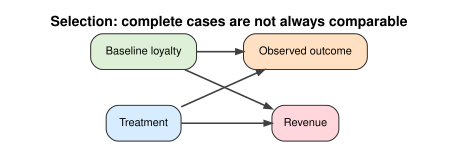

In [19]:
selection_edges = [
    ("Treatment", "Observed outcome"),
    ("Baseline loyalty", "Observed outcome"),
    ("Baseline loyalty", "Revenue"),
    ("Treatment", "Revenue"),
]
selection_colors = {
    "Treatment": COLORS["treatment"],
    "Revenue": COLORS["outcome"],
    "Observed outcome": COLORS["selection"],
    "Baseline loyalty": COLORS["confounder"],
}

display(make_dag(selection_edges, "Selection: complete cases are not always comparable", selection_colors))

In [20]:
def simulate_selection_bias(n=90_000, seed=5):
    rng_local = np.random.default_rng(seed)
    treatment = rng_local.binomial(1, 0.5, size=n)
    loyalty = rng_local.normal(size=n)
    true_effect = 1.00
    revenue = 10.0 + true_effect * treatment + 1.7 * loyalty + rng_local.normal(scale=1.3, size=n)
    # Treatment and loyalty both affect whether the outcome is observed.
    p_observed = 1 / (1 + np.exp(-(-0.25 + 1.00 * treatment + 1.25 * loyalty)))
    observed = rng_local.binomial(1, p_observed)
    return pd.DataFrame({
        "treatment": treatment,
        "loyalty": loyalty,
        "revenue": revenue,
        "observed": observed,
        "p_observed": p_observed,
    }), true_effect

df_sel, true_sel_effect = simulate_selection_bias()

selection_models = {
    "Full data: randomized comparison": smf.ols("revenue ~ treatment", data=df_sel).fit(),
    "Observed only: complete-case comparison": smf.ols("revenue ~ treatment", data=df_sel.query("observed == 1")).fit(),
    "Observed only: adjust for loyalty": smf.ols("revenue ~ treatment + loyalty", data=df_sel.query("observed == 1")).fit(),
}

selection_table = coef_table(selection_models, "treatment")
selection_table.round(3)

,model,coefficient,std_error,lower_95,upper_95,r_squared
0,Full data: randomized comparison,0.993,0.014,0.965,1.021,0.051
1,Observed only: complete-case comparison,0.681,0.018,0.645,0.716,0.028
2,Observed only: adjust for loyalty,0.978,0.012,0.955,1.002,0.582


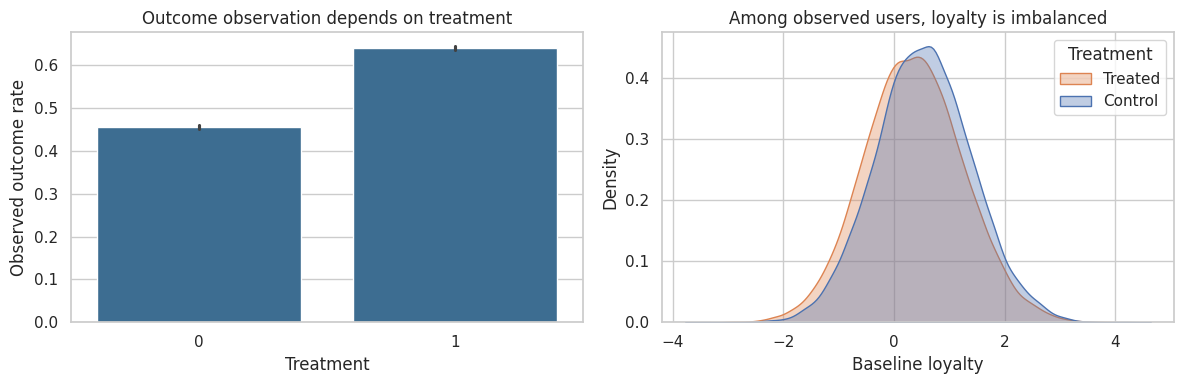

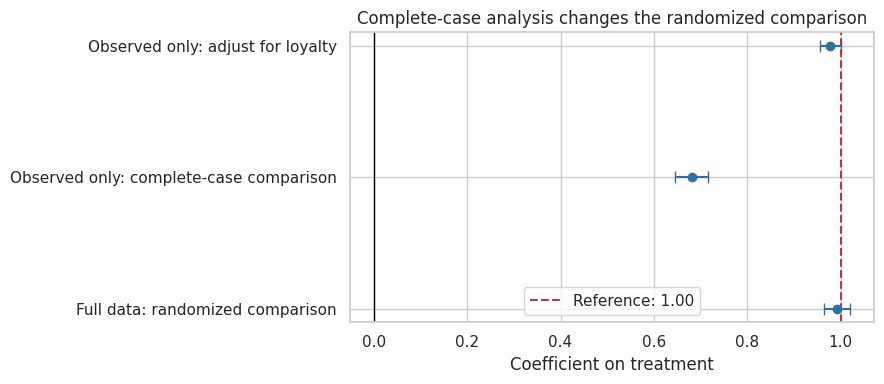

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=df_sel, x="treatment", y="observed", ax=axes[0], color="#2f6f9f")
axes[0].set_title("Outcome observation depends on treatment")
axes[0].set_xlabel("Treatment")
axes[0].set_ylabel("Observed outcome rate")

sns.kdeplot(data=df_sel.query("observed == 1"), x="loyalty", hue="treatment", fill=True, common_norm=False, alpha=0.35, ax=axes[1])
axes[1].set_title("Among observed users, loyalty is imbalanced")
axes[1].set_xlabel("Baseline loyalty")
axes[1].legend(title="Treatment", labels=["Treated", "Control"])

plt.tight_layout()
plt.show()

plot_coef_table(
    selection_table,
    title="Complete-case analysis changes the randomized comparison",
    xlabel="Coefficient on treatment",
    reference=true_sel_effect,
    figsize=(9, 4),
)

### Interpretation

Treatment is randomized in the full population, so the full-data comparison recovers the true effect. But outcome observation depends on both treatment and baseline loyalty. When we restrict to observed outcomes, treatment status becomes associated with loyalty inside the selected sample.

If loyalty is measured, adjusting for it can help. If the selection-driving variable is unmeasured, complete-case analysis may be biased even when treatment was randomized at baseline.

This is a crucial point for experiments: randomization protects treatment assignment at the start. It does not automatically protect analyses after post-treatment attrition, survey response, logging failures, or eligibility filters.

## 10. M-Bias: A Variable Can Look Like a Confounder and Still Be Dangerous

Sometimes a variable is associated with both treatment and outcome because it is a collider between two latent causes. This is often called M-bias because of the shape of the graph:

$$
T \leftarrow U_1 \rightarrow C \leftarrow U_2 \rightarrow Y.
$$

The variable `C` may look tempting because it is associated with treatment and outcome. But conditioning on it opens a path between `U_1` and `U_2`, creating bias between treatment and outcome.

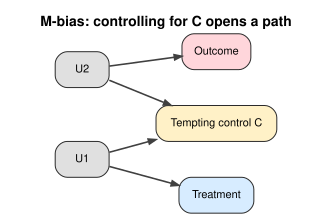

In [22]:
mbias_edges = [
    ("U1", "Treatment"),
    ("U1", "Tempting control C"),
    ("U2", "Tempting control C"),
    ("U2", "Outcome"),
]
mbias_colors = {
    "Treatment": COLORS["treatment"],
    "Outcome": COLORS["outcome"],
    "Tempting control C": COLORS["collider"],
    "U1": COLORS["latent"],
    "U2": COLORS["latent"],
}

display(make_dag(mbias_edges, "M-bias: controlling for C opens a path", mbias_colors))

In [23]:
def simulate_m_bias(n=100_000, seed=6):
    rng_local = np.random.default_rng(seed)
    u1 = rng_local.normal(size=n)
    u2 = rng_local.normal(size=n)
    treatment = 0.9 * u1 + rng_local.normal(size=n)
    control_c = 0.9 * u1 + 0.9 * u2 + rng_local.normal(size=n)
    outcome = 0.0 * treatment + 1.1 * u2 + rng_local.normal(size=n)
    return pd.DataFrame({
        "treatment": treatment,
        "control_c": control_c,
        "outcome": outcome,
        "u1": u1,
        "u2": u2,
    })

df_mbias = simulate_m_bias()

mbias_models = {
    "Naive: Y ~ T": smf.ols("outcome ~ treatment", data=df_mbias).fit(),
    "Adjusted for tempting C": smf.ols("outcome ~ treatment + control_c", data=df_mbias).fit(),
    "Adjusted for true latent U2": smf.ols("outcome ~ treatment + u2", data=df_mbias).fit(),
}

mbias_table = coef_table(mbias_models, "treatment")
mbias_table.round(3)

,model,coefficient,std_error,lower_95,upper_95,r_squared
0,Naive: Y ~ T,-0.002,0.003,-0.009,0.005,0.000
1,Adjusted for tempting C,-0.196,0.003,-0.203,-0.190,0.195
2,Adjusted for true latent U2,-0.001,0.002,-0.006,0.003,0.551


Correlations with tempting control C
           treatment  outcome  control_c
treatment      1.000   -0.002       0.37
outcome       -0.002    1.000       0.41
control_c      0.370    0.410       1.00


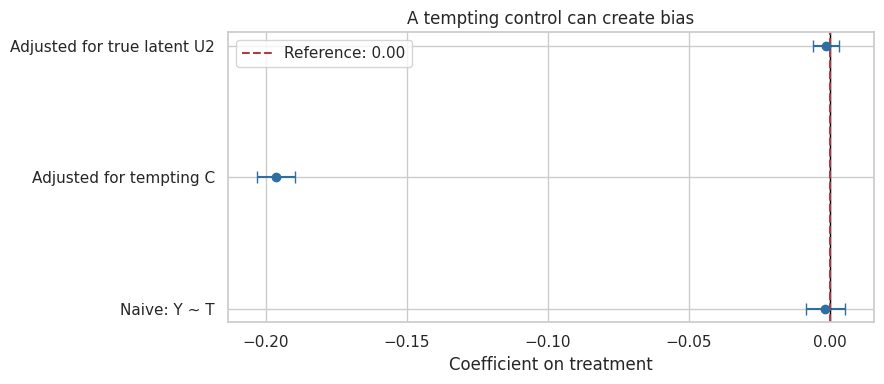

In [24]:
print("Correlations with tempting control C")
print(df_mbias[["treatment", "outcome", "control_c"]].corr().round(3))

plot_coef_table(
    mbias_table,
    title="A tempting control can create bias",
    xlabel="Coefficient on treatment",
    reference=0.0,
    figsize=(9, 4),
)

### Interpretation

The true treatment effect is zero. The naive estimate is near zero. But after adjusting for `C`, a spurious treatment effect appears.

This example is intentionally stylized, but it teaches an important lesson: variable selection based on observed associations can fail. The causal role of the variable determines whether adjustment helps.

## 11. Putting It Together: A Product Analytics Example

Suppose a product team wants to estimate the total effect of a retention offer on 90-day revenue.

Variables in the warehouse include:

- `prior_spend`: customer spend before the offer;
- `risk_score`: model score used to target the offer;
- `offer_opened`: whether the customer opened the offer email;
- `used_coupon`: whether the customer used the coupon;
- `survey_response`: whether the customer answered a satisfaction survey;
- `support_ticket`: whether the customer contacted support after the offer;
- `revenue_90d`: 90-day revenue.

The safest first move is not to run a giant regression. The safest first move is to classify variables by timing and role.

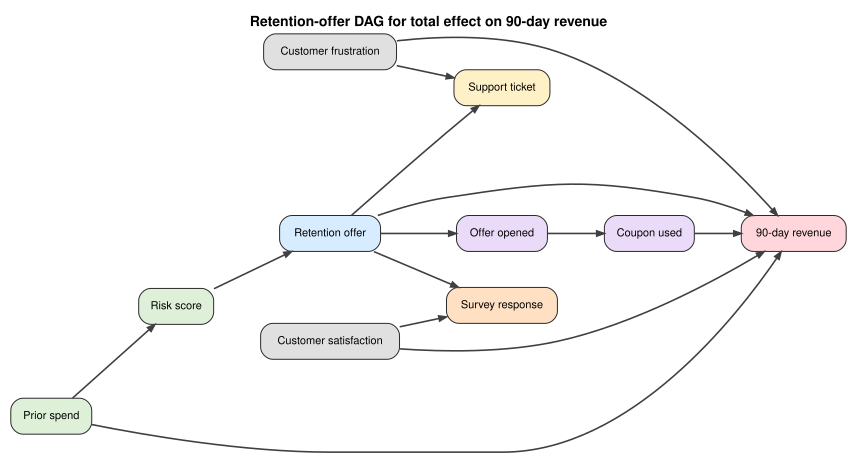

In [25]:
product_edges = [
    ("Prior spend", "Risk score"),
    ("Prior spend", "90-day revenue"),
    ("Risk score", "Retention offer"),
    ("Retention offer", "Offer opened"),
    ("Offer opened", "Coupon used"),
    ("Coupon used", "90-day revenue"),
    ("Retention offer", "90-day revenue"),
    ("Customer frustration", "Support ticket"),
    ("Retention offer", "Support ticket"),
    ("Customer frustration", "90-day revenue"),
    ("Retention offer", "Survey response"),
    ("Customer satisfaction", "Survey response"),
    ("Customer satisfaction", "90-day revenue"),
]
product_colors = {
    "Retention offer": COLORS["treatment"],
    "90-day revenue": COLORS["outcome"],
    "Prior spend": COLORS["confounder"],
    "Risk score": COLORS["confounder"],
    "Offer opened": COLORS["mediator"],
    "Coupon used": COLORS["mediator"],
    "Support ticket": COLORS["collider"],
    "Survey response": COLORS["selection"],
    "Customer frustration": COLORS["latent"],
    "Customer satisfaction": COLORS["latent"],
}

display(make_dag(product_edges, "Retention-offer DAG for total effect on 90-day revenue", product_colors))

In [26]:
product_roles = pd.DataFrame({
    "variable": [
        "Prior spend",
        "Risk score",
        "Offer opened",
        "Coupon used",
        "Support ticket",
        "Survey response",
        "Customer frustration",
        "Customer satisfaction",
    ],
    "timing": [
        "Pre-treatment",
        "Pre-treatment assignment variable",
        "Post-treatment",
        "Post-treatment",
        "Post-treatment",
        "Post-treatment / selection",
        "Partly latent",
        "Partly latent",
    ],
    "likely_role_for_total_effect": [
        "Confounder or precision covariate",
        "Treatment assignment driver; may help block targeting bias",
        "Mediator",
        "Mediator",
        "Collider or post-treatment variable",
        "Selection variable / collider",
        "Unobserved common cause of support and revenue",
        "Unobserved common cause of survey response and revenue",
    ],
    "default_action": [
        "Consider adjusting",
        "Consider adjusting, especially if used for targeting",
        "Do not adjust for total effect",
        "Do not adjust for total effect",
        "Do not adjust blindly",
        "Do not restrict to respondents without a plan",
        "Discuss as sensitivity limitation",
        "Discuss as sensitivity limitation",
    ],
})
product_roles

,variable,timing,likely_role_for_total_effect,default_action
0,Prior spend,Pre-treatment,Confounder or precision covariate,Consider adjusting
1,Risk score,Pre-treatment assignment variable,Treatment assignment driver; may help block ta...,"Consider adjusting, especially if used for tar..."
2,Offer opened,Post-treatment,Mediator,Do not adjust for total effect
3,Coupon used,Post-treatment,Mediator,Do not adjust for total effect
4,Support ticket,Post-treatment,Collider or post-treatment variable,Do not adjust blindly
5,Survey response,Post-treatment / selection,Selection variable / collider,Do not restrict to respondents without a plan
6,Customer frustration,Partly latent,Unobserved common cause of support and revenue,Discuss as sensitivity limitation
7,Customer satisfaction,Partly latent,Unobserved common cause of survey response and...,Discuss as sensitivity limitation


### Interpretation

For the total effect of the retention offer on 90-day revenue, `offer_opened` and `coupon_used` are not ordinary controls. They are part of how the offer works. Controlling for them asks a different question.

`survey_response` is especially dangerous if the analysis uses only survey respondents. Response may be affected by treatment and by customer satisfaction, which also affects revenue. That creates a selection problem.

`prior_spend` and `risk_score` are more plausible adjustment variables because they are measured before treatment and affect targeting or baseline revenue.

## 12. A Practical Adjustment Checklist

Before fitting a causal model, ask these questions for every candidate control variable.

1. **When was it measured?** Before treatment, after treatment, or during selection?
2. **Could treatment cause it?** If yes, it is post-treatment for this estimand.
3. **Could it cause treatment assignment?** If yes, it may be part of targeting or selection into treatment.
4. **Could it cause the outcome?** If yes, it may be a common cause if it also causes treatment.
5. **Could it be caused by two things we care about?** If yes, it may be a collider.
6. **Does conditioning on it define the dataset?** If yes, selection bias may already be present.
7. **What estimand are we targeting?** Total effect, direct effect, indirect effect, effect among selected units, or policy effect?

The checklist is intentionally repetitive. Most adjustment mistakes happen because one of these questions was skipped.

In [27]:
checklist = pd.DataFrame({
    "candidate_variable_question": [
        "Measured before treatment?",
        "Affected by treatment?",
        "Cause of treatment?",
        "Cause of outcome?",
        "Common effect of treatment and another cause?",
        "Determines inclusion in the data?",
        "Needed for the stated estimand?",
    ],
    "if_yes": [
        "Eligible to consider as an adjustment variable",
        "Likely mediator/post-treatment variable; avoid for total effect",
        "Could be part of treatment assignment mechanism",
        "Could be confounder if it also affects treatment",
        "Possible collider; avoid conditioning",
        "Selection issue; analyze target population carefully",
        "Use only if it matches the estimand, not because it predicts well",
    ],
    "evidence_needed": [
        "Timestamp, data lineage",
        "Product logic, experiment design, timing",
        "Targeting policy, eligibility rules, model documentation",
        "Domain knowledge, prior studies, temporal ordering",
        "DAG, selection rules, data-generation process",
        "Logging rules, response/attrition process",
        "Written estimand card",
    ],
})
checklist

,candidate_variable_question,if_yes,evidence_needed
0,Measured before treatment?,Eligible to consider as an adjustment variable,"Timestamp, data lineage"
1,Affected by treatment?,Likely mediator/post-treatment variable; avoid...,"Product logic, experiment design, timing"
2,Cause of treatment?,Could be part of treatment assignment mechanism,"Targeting policy, eligibility rules, model doc..."
3,Cause of outcome?,Could be confounder if it also affects treatment,"Domain knowledge, prior studies, temporal orde..."
4,Common effect of treatment and another cause?,Possible collider; avoid conditioning,"DAG, selection rules, data-generation process"
5,Determines inclusion in the data?,Selection issue; analyze target population car...,"Logging rules, response/attrition process"
6,Needed for the stated estimand?,"Use only if it matches the estimand, not becau...",Written estimand card


## 13. Key Takeaways

- A confounder is a pre-treatment common cause of treatment and outcome.
- Adjusting for confounders can reduce bias by blocking back-door paths.
- A mediator lies on the pathway from treatment to outcome. Adjusting for it changes a total-effect estimand.
- A collider is a common effect. Conditioning on it can create association between its causes.
- Selection bias often arises because the observed dataset is conditioned on a post-treatment or collider-like variable.
- Strong prediction is not the same as valid causal adjustment.
- The right adjustment set is chosen from the DAG and estimand, not from a generic feature-importance ranking.

The applied habit to build is simple: before estimating, classify every variable by timing and causal role. That small discipline prevents a large number of expensive mistakes.

## References

Banack, H. R., Mayeda, E. R., & Fox, M. P. (2024). Collider stratification bias II: Magnitude of bias. *American Journal of Epidemiology, 194*(5), 1149-1151. https://doi.org/10.1093/aje/kwae255

Fulcher, I., Shi, X., & Tchetgen Tchetgen, E. J. (2019). Estimation of natural indirect effects robust to unmeasured confounding and mediator measurement error. *Epidemiology, 30*(6), 825-834. https://doi.org/10.1097/ede.0000000000001084

Greenland, S., Pearl, J., & Robins, J. M. (1999). Causal diagrams for epidemiologic research. *Epidemiology, 10*(1), 37-48. https://doi.org/10.1097/00001648-199901000-00008

Howards, P. P., Schisterman, E. F., & Poole, C. (2012). "Toward a clearer definition of confounding" revisited with directed acyclic graphs. *American Journal of Epidemiology, 176*(6), 506-511. https://doi.org/10.1093/aje/kws127

Lu, H., Gonsalves, G., & Westreich, D. (2023). Selection bias requires selection: The case of collider stratification bias. *American Journal of Epidemiology, 193*(3), 407-409. https://doi.org/10.1093/aje/kwad213

Rijnhart, J. J. M., Valente, M. J., MacKinnon, D. P., Twisk, J. W. R., & Heymans, M. W. (2020). The use of traditional and causal estimators for mediation models with a binary outcome and exposure-mediator interaction. *Structural Equation Modeling: A Multidisciplinary Journal, 28*(3), 345-355. https://doi.org/10.1080/10705511.2020.1811709

Suttorp, M. M., Siegerink, B., Jager, K. J., Zoccali, C., & Dekker, F. W. (2014). Graphical presentation of confounding in directed acyclic graphs. *Nephrology Dialysis Transplantation, 30*(9), 1418-1423. https://doi.org/10.1093/ndt/gfu325

Whitcomb, B. W., Schisterman, E. F., Perkins, N. J., & Platt, R. W. (2009). Quantification of collider-stratification bias and the birthweight paradox. *Paediatric and Perinatal Epidemiology, 23*(5), 394-402. https://doi.org/10.1111/j.1365-3016.2009.01053.x